# Machine Learning for Space Exploration: Pulsar Star Classification (Edge AI)

## Abstract and Project Objectives
Radio telescope observations of the universe generate massive amounts of data (Big Data). The vast majority of the captured signals are simply cosmic background noise (Radio Frequency Interference - RFI), while only a tiny fraction represents genuine emissions from **Pulsar Stars**. 

The goal of this project is to design, train, and evaluate a Machine Learning model capable of autonomously distinguishing noise from pulsars, explicitly optimized for an **Edge AI** application. The model must be lightweight and interpretable enough to be translated into low-level C/C++ code and deployed directly onto a satellite's microcontroller. This allows the raw data to be filtered directly in orbit, saving precious transmission bandwidth back to Earth.

To guarantee scientific rigor, prevent methodological errors (such as data leakage), and systematically compress complex astronomical data into a lightweight logical engine, this project is strictly structured upon the standard **KDD (Knowledge Discovery in Databases)** methodology. 

## The KDD Pipeline Implementation
The project follows a linear, 5-step knowledge extraction process:

1. **Phase 1: Data Selection:** Initial loading and exploratory data analysis (EDA) of the dataset to define the feature space, analyze linear correlations, and establish the baseline class distribution.
2. **Phase 2: Data Preprocessing:** Quality control checks, handling of duplicate records, outlier identification (using the IQR method), and correlation analysis to ensure the integrity of the raw data.
3. **Phase 3: Data Transformation (Edge AI Optimization):** The most critical engineering phase. It involves a strict, leakage-proof train/test split, statistical Feature Selection (ANOVA F-test) to isolate only the top predictors, and Data Discretization to compress continuous variables into discrete categorical bins, simulating hardware memory constraints.
4. **Phase 4: Data Mining:** The actual training of the machine learning algorithms. The focus is exclusively on generating an optimized Decision Tree to extract lightweight, hardware-compatible `if-else` classification rules.
5. **Phase 5: Interpretation and Evaluation:** Rigorous validation of the extracted knowledge using a 5-Fold Stratified Cross-Validation on the discretized data. This proves the model's structural stability, followed by a final benchmark against baseline models (Dummy and Random Forest) to justify the architectural choices.

## Task, Model, and Approach
* **The Task:** Supervised Binary Classification (Class 0: Noise | Class 1: Pulsar).
* **The Dataset:** HTRU_2, containing physical and statistical measurements of the integrated Radio Profile and the Dispersion Curve of the signals. The dataset is highly imbalanced, comprising ~91% background noise and only ~9% actual pulsars.
* **The Model:** A **Decision Tree** trained using Information Theory (Shannon Entropy and Information Gain) and restricted by pre-pruning (`max_depth = 4`). This specific algorithm was chosen over Neural Networks or complex Ensembles because it offers the optimal trade-off between predictive power, extremely low computational cost (RAM/CPU), and total logical interpretability (White-Box model).
* **Evaluation Strategy:** Due to the severe class imbalance, global accuracy alone is a misleading metric. While the model's stability is validated via Cross-Validation, the final benchmark focuses heavily on maximizing the **Recall** and **F1-Score** for the Pulsar class. The primary objective is to minimize False Negatives, ensuring the satellite does not accidentally discard a genuine scientific discovery while aggressively filtering the noise.

## Setup and Library Imports

In [19]:
# Importing dataset
# https://www.kaggle.com/datasets/charitarth/pulsar-dataset-htru2

# Base Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-Learn
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, recall_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import KBinsDiscretizer
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Graphical settings & Display options
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)

# Reproducibility
np.random.seed(42)

## Phase 1: Data Selection

### 1.1 Loading the Dataset

In [20]:
# Defining column names based on the dataset description
col_names = [
    'Mean_P', 'STD_P', 'Kurtosis_P', 'Skewness_P',
    'Mean_C', 'STD_C', 'Kurtosis_C', 'Skewness_C',
    'Target_Class'
]

# Creating the DataFrame by reading the CSV file
df = pd.read_csv('./data/HTRU_2.csv', header=None, names=col_names)

# Mapping target variable to categorical labels
df['Target_Class'] = df['Target_Class'].map({0: 'Noise', 1: 'Pulsar'})

### 1.2 Dataset Overview


Dimensions: 17898 rows x 9 columns

Features Names: ['Mean_P', 'STD_P', 'Kurtosis_P', 'Skewness_P', 'Mean_C', 'STD_C', 'Kurtosis_C', 'Skewness_C']
Target Classes: <StringArray>
['Noise', 'Pulsar']
Length: 2, dtype: str


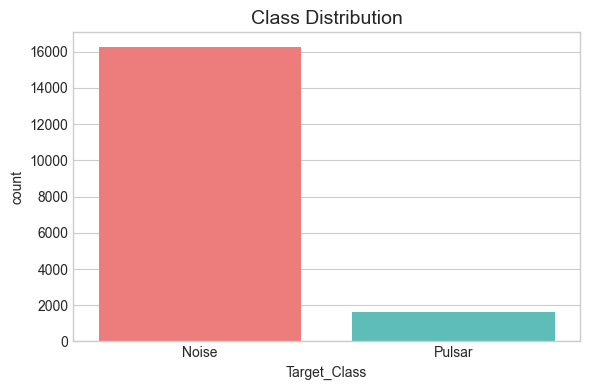

Class distribution: 90.84% Noise, 9.16% Pulsars
Noise: 16259, Pulsars: 1639

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Mean_P        17898 non-null  float64
 1   STD_P         17898 non-null  float64
 2   Kurtosis_P    17898 non-null  float64
 3   Skewness_P    17898 non-null  float64
 4   Mean_C        17898 non-null  float64
 5   STD_C         17898 non-null  float64
 6   Kurtosis_C    17898 non-null  float64
 7   Skewness_C    17898 non-null  float64
 8   Target_Class  17898 non-null  str    
dtypes: float64(8), str(1)
memory usage: 1.2 MB
None

Dataset Overview (first 5 rows):


,Mean_P,STD_P,Kurtosis_P,Skewness_P,Mean_C,STD_C,Kurtosis_C,Skewness_C,Target_Class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,Noise
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,Noise
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,Noise
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,Noise
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,Noise


In [21]:
# Number of rows and columns
print(f"\nDimensions: {df.shape[0]} rows x {df.shape[1]} columns")

# List of feature names and target classes
print(f"\nFeatures Names: {df.columns.tolist()[:-1] }")
print(f"Target Classes: {df['Target_Class'].unique()}")

# Class distribution
class_counts = df['Target_Class'].value_counts()

# Visualizing class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Target_Class', hue='Target_Class', palette=['#FF6B6B', '#4ECDC4'], legend=False)
plt.title('Class Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# Displaying class distribution statistics
print(f"Class distribution: {class_counts['Noise']/len(df)*100:.2f}% Noise, {class_counts['Pulsar']/len(df)*100:.2f}% Pulsars")
print(f"Noise: {class_counts['Noise']}, Pulsars: {class_counts['Pulsar']}")

# Dataset information
print(f"\nDataset Information:")
print(df.info())

# Dataset overview
print(f"\nDataset Overview (first 5 rows):")
display(df.head())

### Phase 1: Summary & Insights

In this initial **Data Selection** phase, the HTRU_2 dataset was imported and a preliminary exploratory data analysis was conducted to inspect its dimensions, data types, and target labels. The objective was to establish a clear foundational overview of the raw data before applying any preprocessing or transformation steps.

A severe structural imbalance within the dataset was identified, with genuine Pulsar emissions accounting for a mere 9.16% of the samples, completely overwhelmed by cosmic background noise (90.84%). This critical insight dictates the evaluation strategy for the remainder of the KDD pipeline: it demonstrates that relying on global accuracy would be statistically misleading, requiring a strict prioritization of the Recall metric to guarantee that no rare, authentic scientific discoveries are erroneously discarded by the satellite.

## Phase 2: Data Preprocessing

### 2.1 Missing Values Check

In [22]:
# Displaying missing values statistics
print("\nMissing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Missing values per column:
Mean_P          0
STD_P           0
Kurtosis_P      0
Skewness_P      0
Mean_C          0
STD_C           0
Kurtosis_C      0
Skewness_C      0
Target_Class    0
dtype: int64

Total missing values: 0


### 2.2 Duplicate Check and Removal

In [23]:
# Displaying duplicate rows statistics
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}\n")

if duplicate_rows > 0:

    print("Duplicate rows:")
    display(df[df.duplicated(keep=False)])

    df = df.drop_duplicates()
    print(f"Dimensions after removing duplicates: {df.shape[0]} rows x {df.shape[1]} columns")
    
else:

    print("No duplicate rows found")


Number of duplicate rows: 0

No duplicate rows found


### 2.3 Outlier Detection

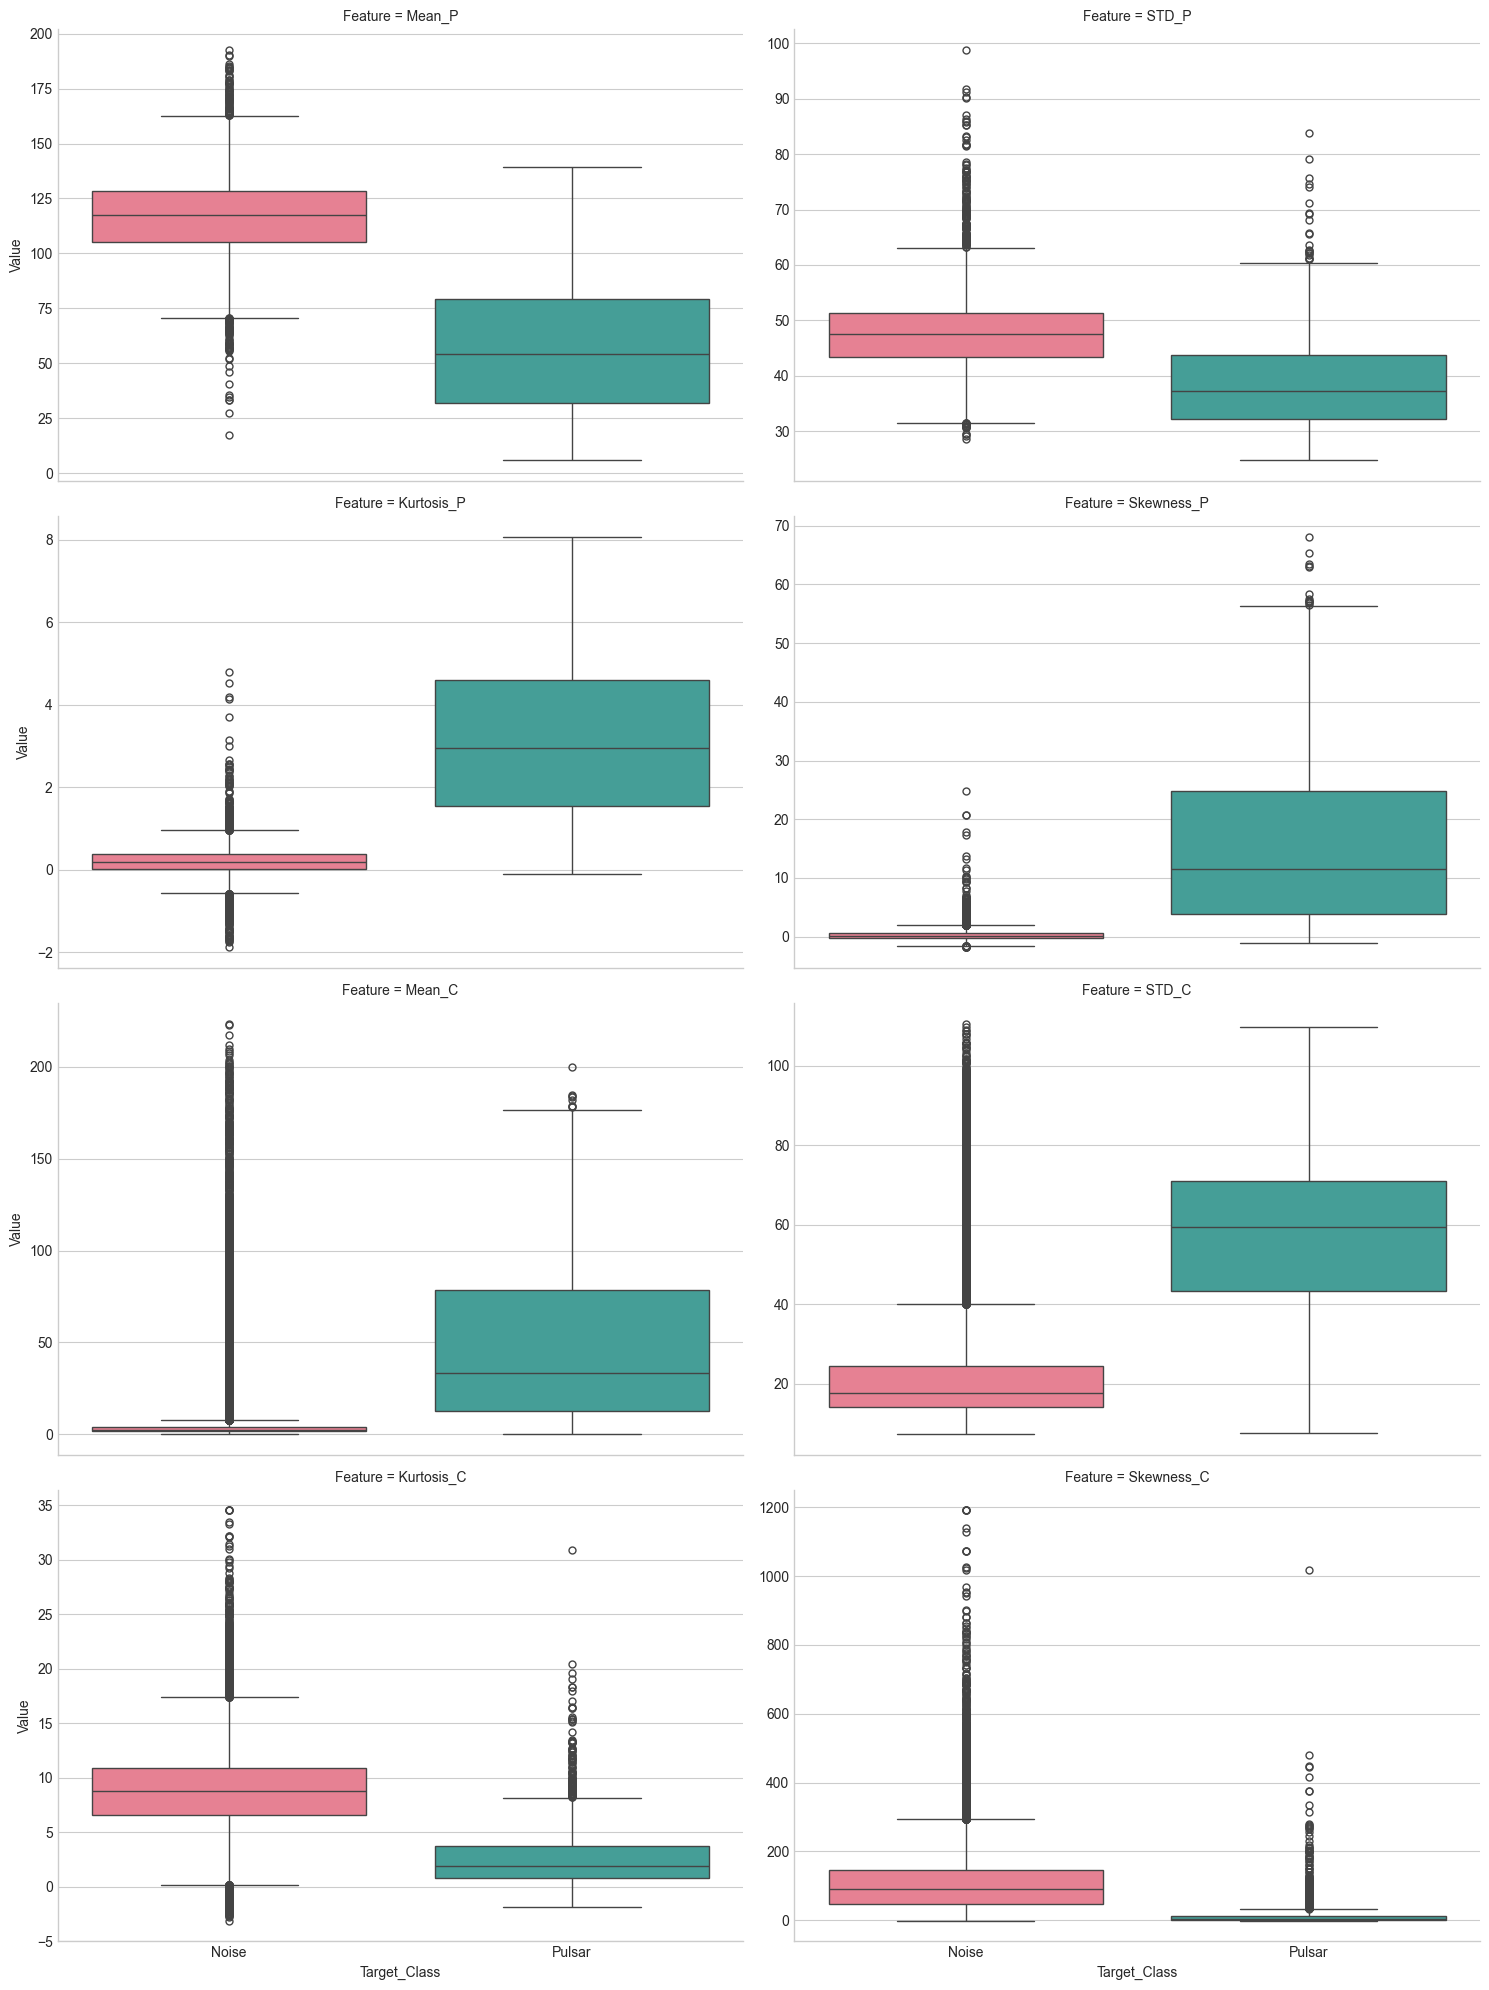

Outlier identification (IQR method):
Noise - Mean_P: 142 outlier (bounds: [70.71, 162.83])
Noise - STD_P: 150 outlier (bounds: [31.49, 63.21])
Noise - Kurtosis_P: 392 outlier (bounds: [-0.57, 0.97])
Noise - Skewness_P: 1078 outlier (bounds: [-1.55, 1.99])
Noise - Mean_C: 2118 outlier (bounds: [-1.70, 7.78])
Noise - STD_C: 1668 outlier (bounds: [-1.43, 40.09])
Noise - Kurtosis_C: 999 outlier (bounds: [0.14, 17.41])
Noise - Skewness_C: 908 outlier (bounds: [-99.79, 293.20])
Pulsar - Mean_P: 0 outlier (bounds: [-39.47, 150.53])
Pulsar - STD_P: 21 outlier (bounds: [15.07, 60.97])
Pulsar - Kurtosis_P: 0 outlier (bounds: [-2.99, 9.13])
Pulsar - Skewness_P: 12 outlier (bounds: [-27.81, 56.50])
Pulsar - Mean_C: 8 outlier (bounds: [-85.57, 176.64])
Pulsar - STD_C: 0 outlier (bounds: [1.86, 112.46])
Pulsar - Kurtosis_C: 104 outlier (bounds: [-3.67, 8.14])
Pulsar - Skewness_C: 212 outlier (bounds: [-20.78, 34.02])


In [24]:
# Boxplots for each feature by class
df_melted = df.melt(id_vars='Target_Class', value_vars=df.columns[:-1], var_name='Feature', value_name='Value')
sns.catplot(data=df_melted, kind='box', x='Target_Class', y='Value', hue='Target_Class', col='Feature', col_wrap=2, sharey=False, palette='husl', height=5, aspect=1.5, legend=False)
plt.show()

# IQR method for identifying outliers
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Visualizing outliers and displaying statistics
print("Outlier identification (IQR method):")
for Target_Class in df['Target_Class'].unique():
    for col in df.columns[:-1]:
        subset = df[df['Target_Class'] == Target_Class]
        outliers, lb, ub = detect_outliers_iqr(subset, col)
        print(f"{Target_Class} - {col}: {len(outliers)} outlier (bounds: [{lb:.2f}, {ub:.2f}])")

### 2.4 Correlation Matrix

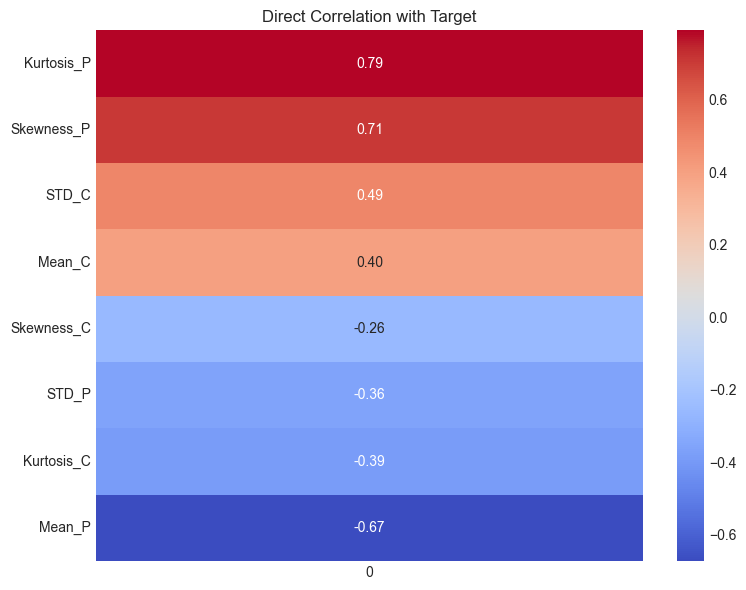

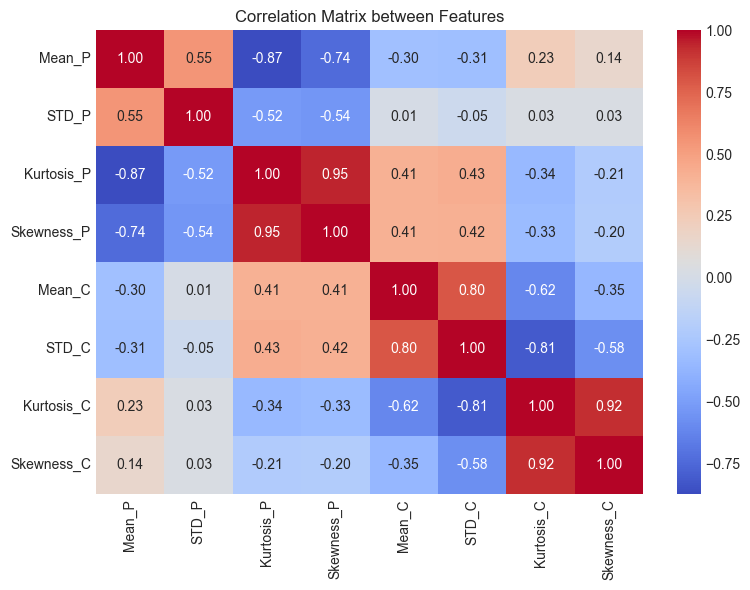

In [25]:
# Reconverting target variable to numerical for calculation
df['Target_Class'] = df['Target_Class'].map({'Noise': 0, 'Pulsar': 1})

# Direct Correlation with Target
correlation_target = df.drop(columns='Target_Class').corrwith(df['Target_Class']).sort_values(ascending=False)

# Visualizing correlation with target variable
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_target.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Direct Correlation with Target")
plt.tight_layout()
plt.show()

# Correlation Matrix between features
correlation_matrix = df.drop(columns=['Target_Class'], errors='ignore').select_dtypes(include=np.number).corr()

# Visualizing correlation matrix between features
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix between Features")
plt.tight_layout()
plt.show()

### Phase 2: Summary & Insights

In this **Data Preprocessing** phase, a comprehensive quality control protocol was executed to ensure the structural integrity of the raw data. After confirming the total absence of missing values and duplicate records, a deep statistical analysis of the radio signal distributions was conducted using Boxplots. These visual tools are essential for quantifying data dispersion, clearly isolating the median, the interquartile range (IQR), and the structural tails of each variable. 

The IQR mathematical assessment detected a substantial number of statistical outliers across multiple features. However, within the specific context of deep-space radio astronomy, these extreme values do not denote sensor malfunctions or corrupted telemetry; rather, they represent genuine physical anomalies, such as severe cosmic noise fluctuations (RFI) or the rare, hidden energy signatures of actual pulsars. Consequently, a strict engineering decision was made to retain all outliers. Removing them would artificially truncate the signal profile and destroy critical edge-case information, whereas the subsequent use of quantile-based discretization and Decision Tree logic will intrinsically manage these extreme values without bias.

Subsequently, a Correlation Matrix was generated to investigate the linear dependencies within the dataset. Crucially, this analysis was utilized to measure both the feature-to-target correlation and the internal multicollinearity (feature-to-feature correlation) among the independent variables. The matrix exposed strong linear relationships between specific feature pairs, most notably between `Kurtosis_Profile` and `Skewness_Profile`. While high internal multicollinearity can severely destabilize traditional parametric algorithms (such as Logistic Regression), it poses no threat to the chosen computational architecture. The Decision Tree classifier is structurally immune to linear redundancy, as it evaluates the Information Gain of each feature independently during node formulation. Therefore, no dimensionality reduction or preventative feature exclusion was performed during preprocessing, ensuring that the maximum amount of raw physical data was preserved for the subsequent algorithmic transformation.

## Phase 3: Data Transformation

### 3.1 Separating features and target variable 

In [26]:
# Preparing features and target variable
X = df.drop('Target_Class', axis=1)
y = df['Target_Class']

# Displaying features and target variable
print("\nFeatures (X) and Target (y) (first 5 rows):")
display(X.head())
display(y)


Features (X) and Target (y) (first 5 rows):


,Mean_P,STD_P,Kurtosis_P,Skewness_P,Mean_C,STD_C,Kurtosis_C,Skewness_C
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306


0        0
1        0
2        0
3        0
4        0
        ..
17893    0
17894    0
17895    0
17896    0
17897    0
Name: Target_Class, Length: 17898, dtype: int64

### 3.2 Dataset Split

In [27]:
# Splitting dataset into training and test sets with stratification to maintain class distribution (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Displaying dataset dimensions and class distribution in training and test sets
print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Class distribution in the training set: {np.bincount(y_train)}")
print(f"Class distribution in the test set: {np.bincount(y_test)}")


Training set: 14318 samples
Test set: 3580 samples
Class distribution in the training set: [13007  1311]
Class distribution in the test set: [3252  328]


### 3.3 Feature Selection


Selected features: ['Mean_P', 'Kurtosis_P', 'Skewness_P', 'STD_C']


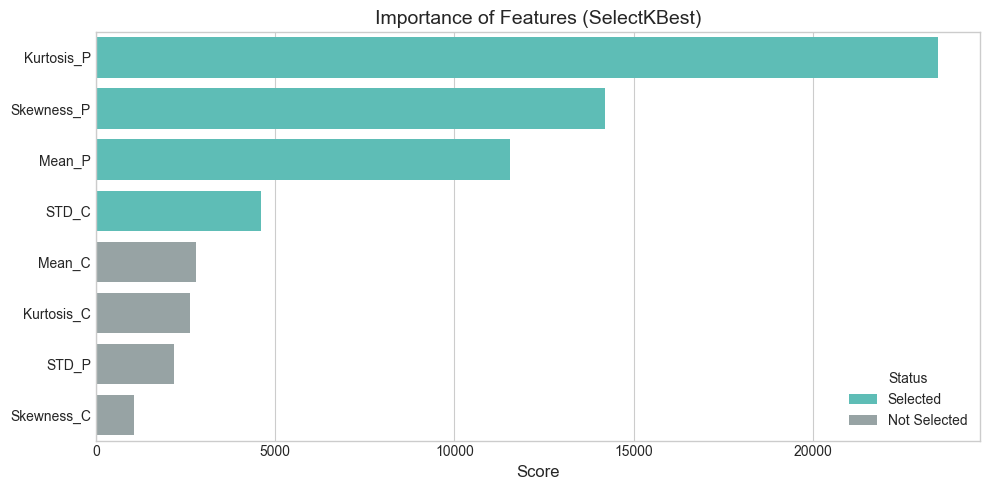

Feature Selection - SelectKBest (ANOVA F-test):
      Feature         Score  Selected        Status
2  Kurtosis_P  23480.764256      True      Selected
3  Skewness_P  14210.468618      True      Selected
0      Mean_P  11554.587657      True      Selected
5       STD_C   4607.083897      True      Selected
4      Mean_C   2788.071758     False  Not Selected
6  Kurtosis_C   2626.047069     False  Not Selected
1       STD_P   2168.486877     False  Not Selected
7  Skewness_C   1056.351220     False  Not Selected


In [28]:
# Selecting top 4 features using ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=4)

# Transforming training and test sets based on selected features
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Getting selected feature names
selected_features = df.columns[:-1][selector.get_support()]
print(f"\nSelected features: {selected_features.tolist()}")

# Creating a DataFrame to display feature scores and selection status
feature_scores = pd.DataFrame({
    'Feature': df.columns[:-1],
    'Score': selector.scores_,
    'Selected': selector.get_support()
}).sort_values('Score', ascending=False)

# Visualizing features importance
feature_scores['Status'] = feature_scores['Selected'].map({True: 'Selected', False: 'Not Selected'})
plt.figure(figsize=(10, 5))
sns.barplot(data=feature_scores, x='Score', y='Feature', hue='Status', palette={'Selected': '#4ECDC4', 'Not Selected': '#95a5a6'}, dodge=False)
plt.title('Importance of Features (SelectKBest)', fontsize=14)
plt.xlabel('Score', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

# Displaying feature scores and selection status
print("Feature Selection - SelectKBest (ANOVA F-test):")
print(feature_scores)

### 3.4 Discretization (Binning)

In [29]:
# Discretization of selected features using KBinsDiscretizer
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile', quantile_method='averaged_inverted_cdf')

# Discretization of the selected features
X_train_binned_array = discretizer.fit_transform(X_train_selected)
X_test_binned_array = discretizer.transform(X_test_selected)

# Continuous data (4 selected features)
X_train_continuous = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train.index)
X_test_continuous = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test.index)

# Binned data (4 selected features)
X_train_binned = pd.DataFrame(X_train_binned_array, columns=selected_features, index=X_train.index)
X_test_binned = pd.DataFrame(X_test_binned_array, columns=selected_features, index=X_test.index)

# Displaying transformed data dimensions and saving the state for future use
print("\nData transformation and state saving completed!")
print(f"\nContinuous Data - Train: {X_train_continuous.shape}")
print(f"Binned Data - Train: {X_train_binned.shape} | Test: {X_test_binned.shape}")


Data transformation and state saving completed!

Continuous Data - Train: (14318, 4)
Binned Data - Train: (14318, 4) | Test: (3580, 4)


### Phase 3: Summary & Insights

In this **Data Transformation** phase, the raw exploratory data was systematically engineered into a format optimized for the final Edge AI algorithm. Initially, the independent physical measurements (features) were separated from the target variable. Subsequently, a rigorous train/test split was executed, partitioning the dataset into an 80% Training Set (14,318 signals) and a 20% Test Set (3,580 signals). The `stratify=y` parameter was strictly enforced to ensure that the severe minority-to-majority class imbalance (~9% pulsars to ~91% noise) was mathematically preserved across both subsets, preventing skewed algorithmic evaluations. Furthermore, the randomization seed (`random_state=42`) was locked to guarantee perfectly deterministic and reproducible results for all subsequent training phases.

Following the dataset split, a targeted dimensionality reduction was performed using the ANOVA F-test (`SelectKBest`) to isolate the top four most informative predictors (`Kurtosis_P`, `Skewness_P`, `Mean_P`, and `STD_C`). Crucially, complex feature extraction techniques, such as Principal Component Analysis (PCA), were strictly avoided. While PCA effectively reduces dimensionality by projecting data into abstract orthogonal components, it irreversibly destroys the physical interpretability of the variables—a mandatory requirement for validating astronomical models. Furthermore, executing PCA inference on an Edge AI satellite microcontroller would introduce unacceptable computational bottlenecks, demanding continuous floating-point matrix multiplications and storing projection weights in highly constrained RAM. By relying exclusively on direct Feature Selection ($K=4$), uninformative variables are dropped natively, ensuring the hardware only processes the raw, meaningful telemetry at zero additional computational cost. This approach perfectly corroborates the feature-to-target Correlation Matrix analyzed in Phase 2. Although Decision Trees are inherently capable of automatic internal feature selection, preemptively isolating this exact mathematical combination aggressively streamlines the pipeline for hardware deployment.

Finally, the continuous radio frequency measurements of the selected features were transformed via data discretization (binning) using a `KBinsDiscretizer`, dividing them into three balanced categorical tiers (Low, Medium, and High). Although the previous Boxplot analysis revealed varying spatial scales across the features, traditional feature scaling techniques were intentionally bypassed for precise mathematical reasons. Specifically, **Normalization (Min-Max scaling)** was strictly unfeasible: because extreme physical outliers were deliberately retained during preprocessing, applying Min-Max scaling would have severely compressed the core signal distributions into an indistinguishable range, destroying valuable variance. Conversely, while **Standardization (Z-score scaling)** could theoretically have been applied to handle the varying scales, it was ultimately deemed unnecessary. Decision Trees calculate Information Gain using orthogonal splits and are fundamentally invariant to monotonic scaling or Euclidean distances. Instead, the chosen binning strategy intrinsically neutralizes the extreme outliers while perfectly aligning the data with the discrete logic gates required by the model. Most importantly, by executing this discretization step strictly *after* the train/test split—calculating the mathematical thresholds exclusively on the Training Set and only applying them to the Test Set—the critical risk of data leakage was completely eliminated, guaranteeing that the final model evaluates genuinely unseen cosmic data without artificial bias.

## Phase 4: Data Mining

### 4.1 Classification - Supervised Algorithm (Decision Tree)

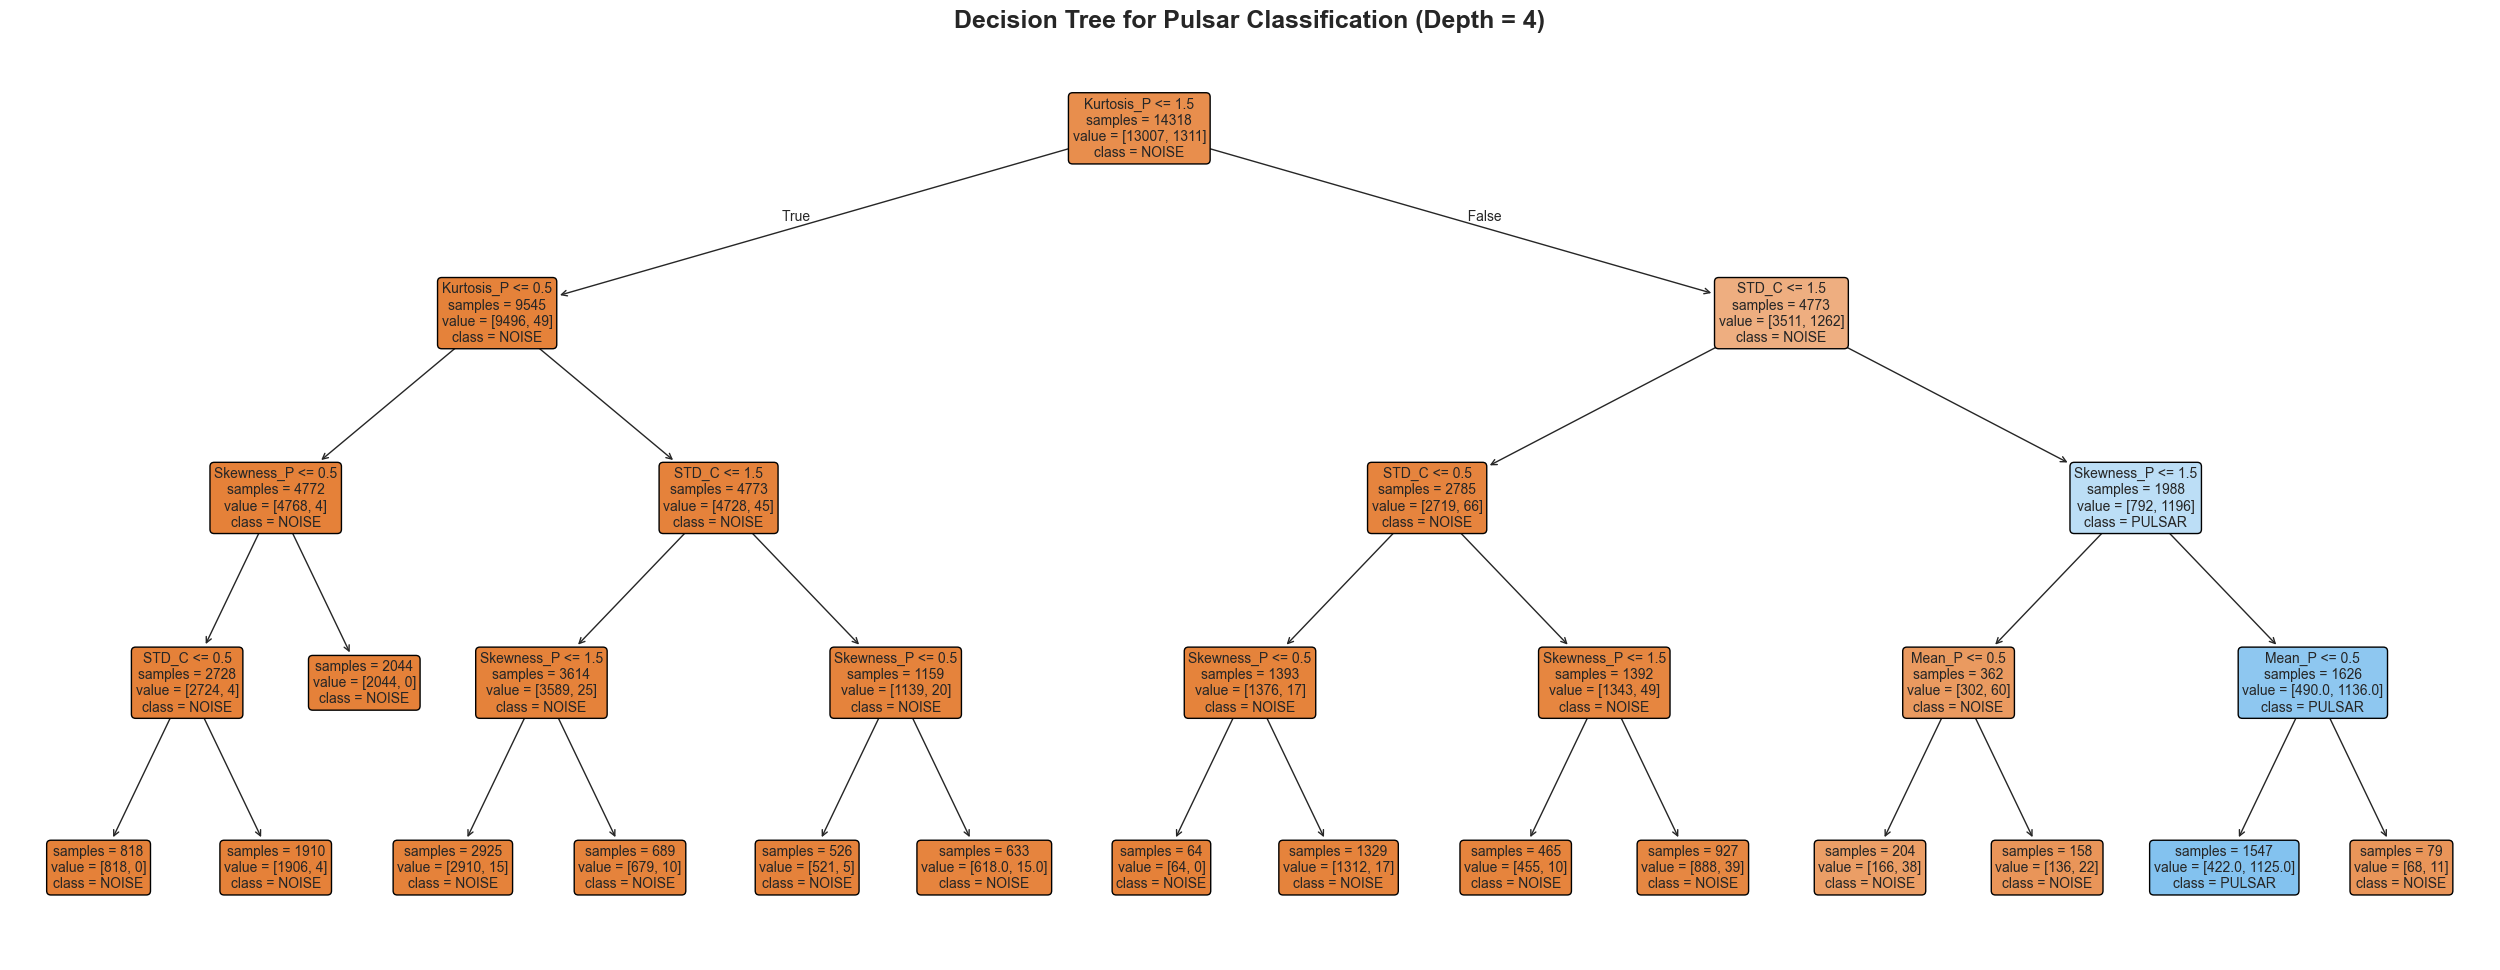

In [30]:
# Training the Decision Tree Classifier
clf = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
clf.fit(X_train_binned, y_train)
y_pred = clf.predict(X_test_binned)

# Visualizing the Decision Tree
plt.figure(figsize=(32, 12))
tree.plot_tree(clf, feature_names=selected_features, class_names=['NOISE', 'PULSAR'], filled=True, impurity=False, rounded=True, fontsize=10)
plt.title("Decision Tree for Pulsar Classification (Depth = 4)", fontsize=18, fontweight='bold')
plt.show()

### 4.2 Classification - Supervised Algorithm (Decision Tree) [Simplified View]

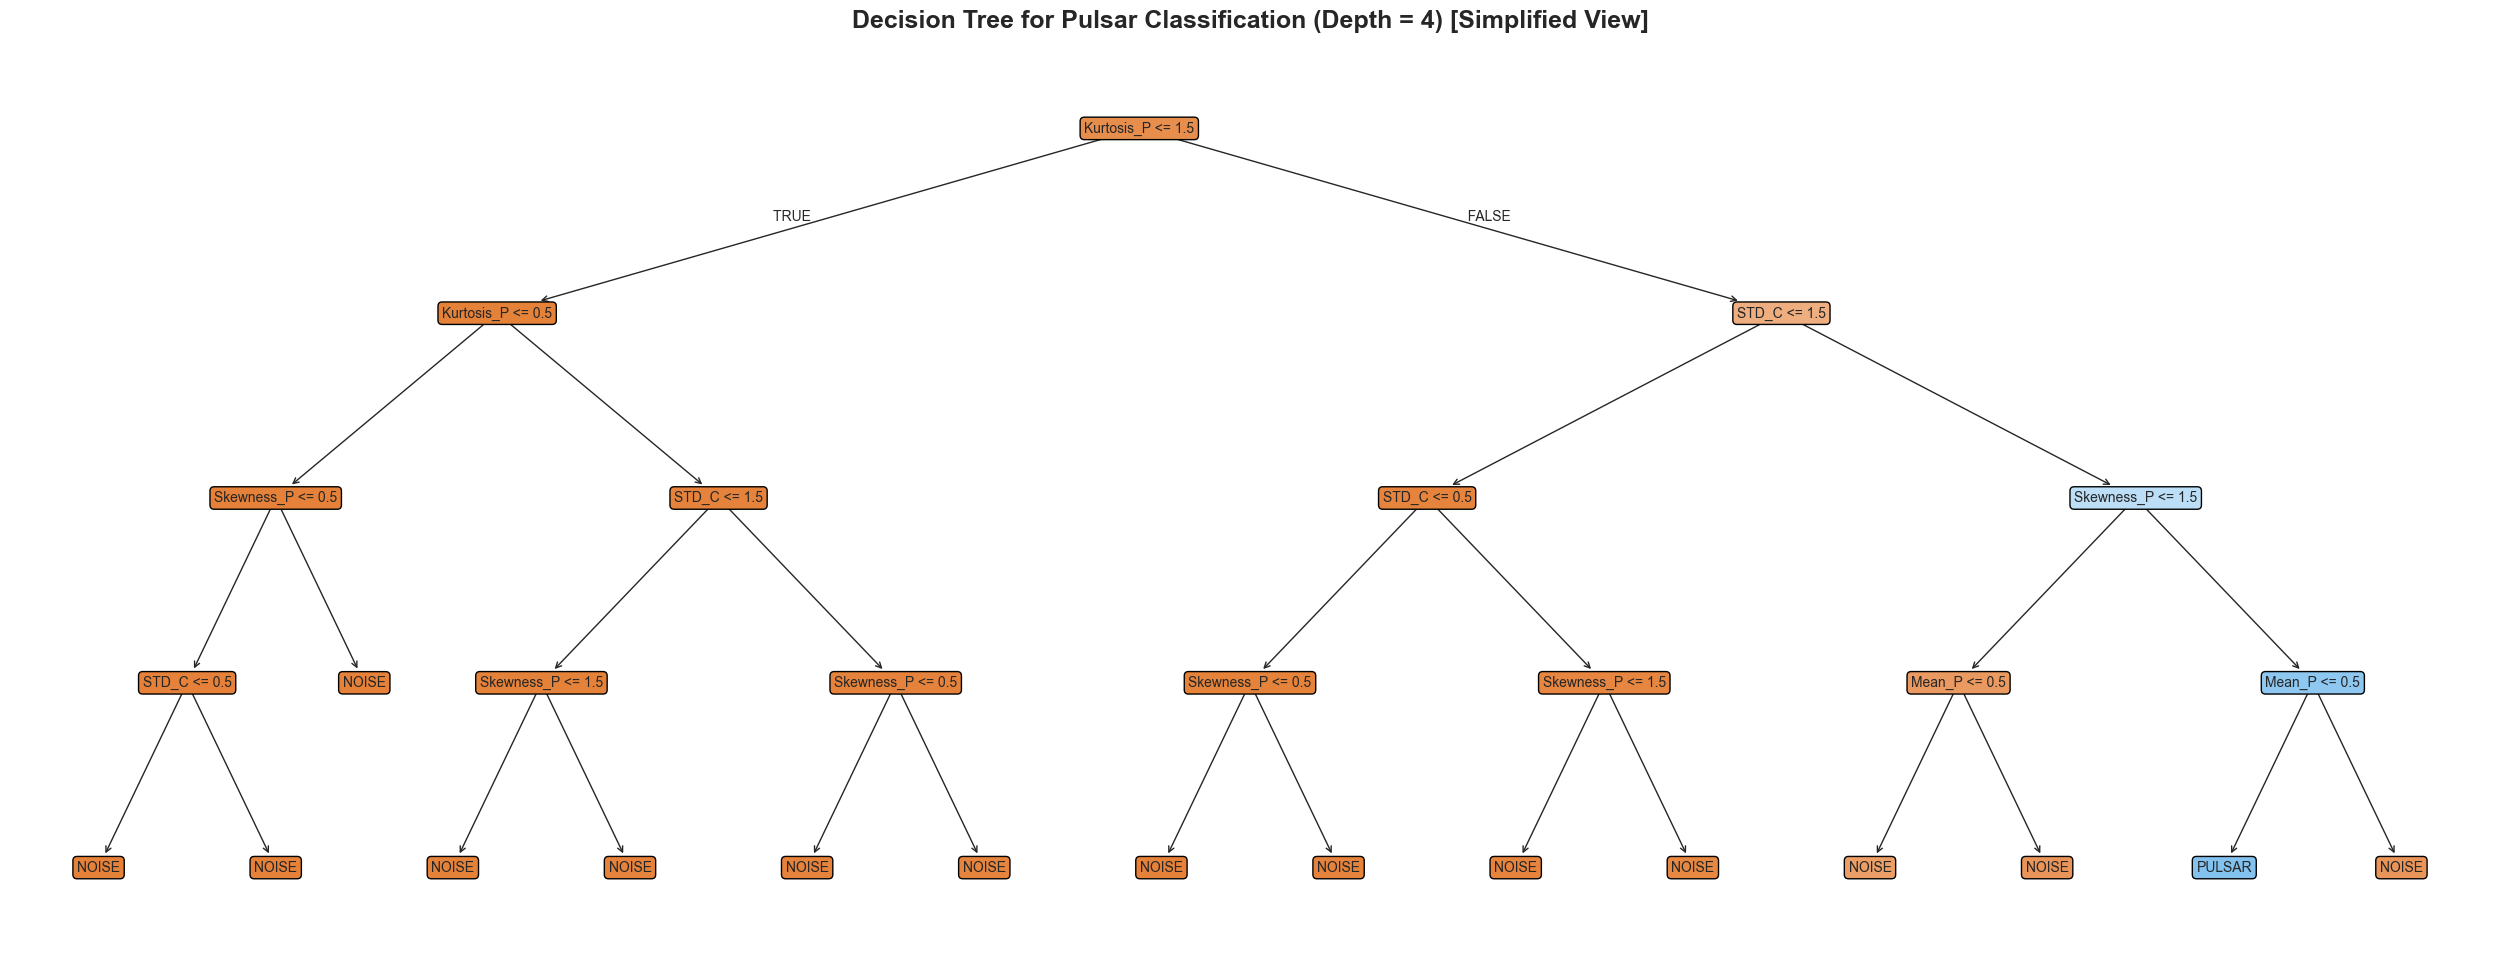

In [31]:
# Visualizing the Decision Tree with simplified node labels
plt.figure(figsize=(32, 12))

tree_plot = tree.plot_tree(
    clf,
    feature_names=selected_features,
    class_names=['Noise', 'Pulsar'],
    filled=True,
    rounded=True,
    fontsize=10
)

for text in tree_plot:

    node_string = text.get_text()
    
    if '<=' in node_string:                                         # decision node
        rule = node_string.split('\n')[0]
        text.set_text(rule)
    else:                                                           # leaf node
        final_class = node_string.split('\n')[-1]
        clean_class = final_class.replace('class = ', '').upper()
        text.set_text(clean_class)

plt.title("Decision Tree for Pulsar Classification (Depth = 4) [Simplified View]", fontsize=18, fontweight='bold')
plt.show()

### Phase 4: Summary & Insights

In this **Data Mining** phase, the predictive model was trained using a **Decision Tree Classifier** explicitly configured to operate as an efficient Edge AI engine. **Shannon Entropy** was utilized as the splitting criterion, directing the algorithm to dynamically calculate the **Information Gain** at every node to maximize the mathematical separation between cosmic noise and authentic celestial signals. To guarantee that the model remains lightweight and robust against overfitting, **pre-pruning** was applied by enforcing a strict **`max_depth` of 4**. Finally, a fixed randomization seed (`random_state=42`) was set to ensure that the training process and the resulting tree topology remain perfectly deterministic and reproducible.

The executed training successfully compressed the continuous statistical data into a streamlined, deterministic decision logic relying entirely on the four previously selected features. The visual extraction of the tree topology revealed a singular, high-precision logical path necessary to identify a genuine **Pulsar**: it explicitly requires a **High `Kurtosis_P`** (bin 2), a **High `STD_C`** (bin 2), a **High `Skewness_P`** (bin 2), and a **Low `Mean_P`** (bin 0). By isolating this specific physical signature, the algorithm yielded a highly interpretable, **white-box model** consisting solely of elementary conditional splits. This lean architecture guarantees that the decision logic can be directly translated into low-level **C/C++** firmware, providing a highly efficient signal filtering system ready for immediate deployment on resource-constrained satellite microcontrollers.

## Phase 5: Interpretation and Evaluation

### 5.1 Model Evaluation

Baseline Model (Dummy Classifier) - Classification Report:
              precision    recall  f1-score   support

       Noise       0.91      1.00      0.95      3252
      Pulsar       0.00      0.00      0.00       328

    accuracy                           0.91      3580
   macro avg       0.45      0.50      0.48      3580
weighted avg       0.83      0.91      0.86      3580

Decision Tree Classifier - Classification Report:
              precision    recall  f1-score   support

       Noise       0.99      0.97      0.98      3252
      Pulsar       0.75      0.86      0.80       328

    accuracy                           0.96      3580
   macro avg       0.87      0.92      0.89      3580
weighted avg       0.96      0.96      0.96      3580

Random Forest Classifier - Classification Report:
              precision    recall  f1-score   support

       Noise       0.99      0.97      0.98      3252
      Pulsar       0.75      0.86      0.80       328

    accuracy           

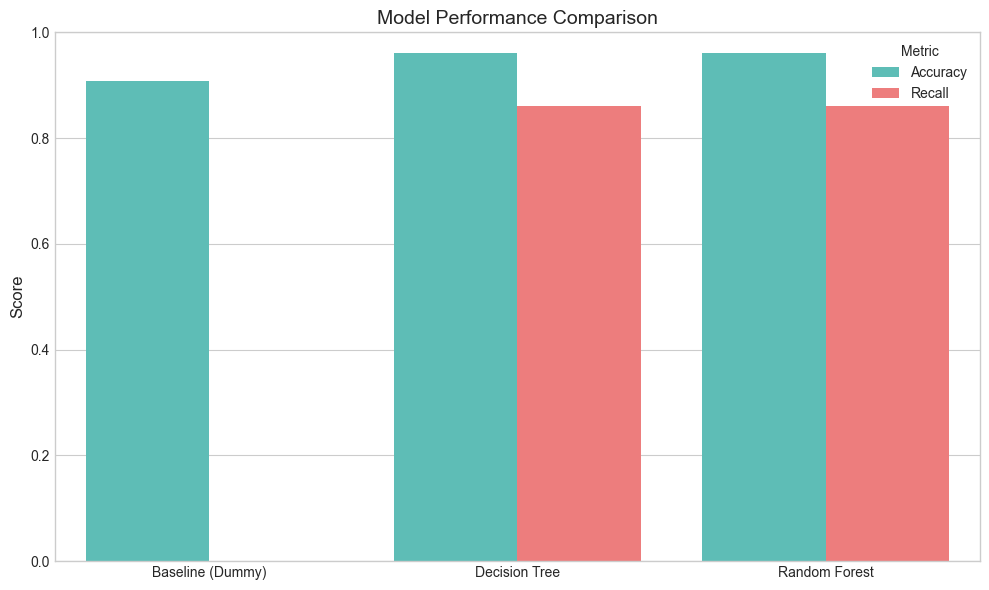

In [32]:
# Baseline Model (always predicts "Class 0 / Noise")
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train_binned, y_train)
dummy_pred = dummy_clf.predict(X_test_binned)

# Advanced Model (Random Forest)
rf_clf = RandomForestClassifier(random_state=42, max_depth=4)
rf_clf.fit(X_train_binned, y_train)
rf_pred = rf_clf.predict(X_test_binned)

# Comparing performance of the models using classification reports
print("Baseline Model (Dummy Classifier) - Classification Report:")
print(classification_report(y_test, dummy_pred, target_names=['Noise', 'Pulsar'], zero_division=0))
print("Decision Tree Classifier - Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Noise', 'Pulsar']))
print("Random Forest Classifier - Classification Report:")
print(classification_report(y_test, rf_pred, target_names=['Noise', 'Pulsar']))

# Performance Comparison
models = [
    'Baseline (Dummy)',
    'Decision Tree',
    'Random Forest'
]
accuracies = [
    accuracy_score(y_test, dummy_pred),
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, rf_pred)
]
recalls = [
    recall_score(y_test, dummy_pred, pos_label=1),
    recall_score(y_test, y_pred, pos_label=1),
    recall_score(y_test, rf_pred, pos_label=1)
]

# Visualizing Performance Comparison
df_metrics = pd.DataFrame({'Model': models, 'Accuracy': accuracies, 'Recall': recalls})
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette={'Accuracy': '#4ECDC4', 'Recall': '#FF6B6B'})
plt.title('Model Performance Comparison', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xlabel('')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### 5.2 Confusion Matrix

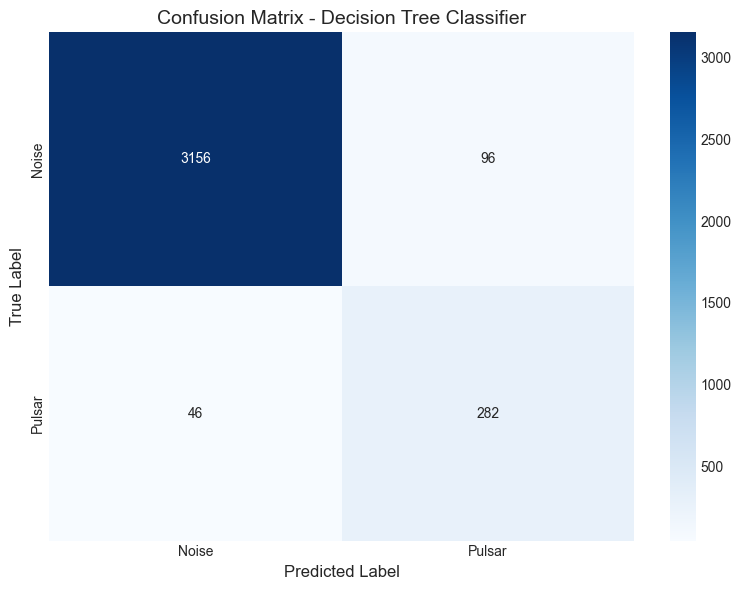

In [33]:
# Creating Confusion Matrix for the Decision Tree Classifier
cm = confusion_matrix(y_test, y_pred)

# Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Noise', 'Pulsar'], yticklabels=['Noise', 'Pulsar'])
plt.title('Confusion Matrix - Decision Tree Classifier', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

### 5.3 Cross Validation

In [34]:
# Creating pipeline for cross-validation with discretization and Decision Tree Classifier
pipeline = make_pipeline(discretizer, clf)

# Cross-validation with recall
cv_scores = cross_val_score(pipeline, X_train_continuous, y_train, cv=5, scoring='recall')

# Displaying cross-validation results
print(f"Cross-validation Recall scores (Decision Tree): {cv_scores}")
print(f"Mean CV Recall: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-validation Recall scores (Decision Tree): [0.87452471 0.85114504 0.84732824 0.85496183 0.86259542]
Mean CV Recall: 0.8581 ± 0.0096


### Phase 5: Summary & Insights

In this **Interpretation and Evaluation** phase, a rigorous benchmarking protocol was executed to validate the final model's predictive power and its specific suitability for Edge AI deployment. Leveraging the binary mapping (**0** for Noise, **1** for Pulsar) already performed in the previous phase specifically to enable the **Confusion Matrix**, the custom Decision Tree was evaluated against a Dummy Classifier (representing the naive baseline) and a Random Forest ensemble (representing state-of-the-art complexity). To assess the model's structural robustness, a 5-Fold Cross-Validation was performed. Crucially, this validation was executed using a Scikit-Learn `Pipeline`; by recalculating the data discretization thresholds dynamically within each isolated training fold, the critical risk of **data leakage** was definitively eliminated. Throughout this entire phase, the evaluation strictly prioritized the **Recall** metric for the positive class over global Accuracy—a mandatory engineering choice dictated by the extreme 91% class imbalance, where missing a rare cosmic anomaly (a False Negative) represents the most severe system failure.

The resulting metrics provided definitive proof of the system's reliability and architectural efficiency. The Dummy Classifier exposed the mathematical deception of global accuracy in imbalanced datasets, achieving a 91% score while failing to detect a single true signal (Recall of 0.00). In stark contrast, the Confusion Matrix revealed that the custom Decision Tree successfully isolated the vast majority of target signals (**282 True Positives**) against only **46 False Negatives**, achieving a remarkable Pulsar Recall of 0.86 and a robust F1-Score of 0.80. The stringent Cross-Validation further validated this stability, returning a Mean Recall of ~0.858 with a marginal standard deviation (±0.0096), proving the model is highly generalizable and free from overfitting. Most importantly, the comparative analysis demonstrated that this single, heavily pruned Decision Tree perfectly matched the sensitivity of the mathematically heavier Random Forest algorithm. In conclusion, by isolating the exact physical signature of a pulsar and transforming it into a highly interpretable sequence of deterministic logic gates, the model successfully balances absolute computational efficiency with maximum scientific discovery potential, proving to be the optimal hardware-ready solution for deep-space signal filtering on resource-constrained satellite microcontrollers.

## Deployment - Model Exportation & Example of Use

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier
import joblib

col_names = [
    'Mean_Profile', 'STD_Profile', 'Kurtosis_Profile', 'Skewness_Profile',
    'Mean_Curve', 'STD_Curve', 'Kurtosis_Curve', 'Skewness_Curve',
    'Target_Class'
]

# 1. Loading Dataset
df = pd.read_csv('./data/HTRU_2.csv', header=None, names=col_names)

# 2. Selecting features and target variable
selected_features = ['Mean_Profile', 'Kurtosis_Profile', 'Skewness_Profile', 'STD_Curve']
X = df[selected_features]
y = df['Target_Class']

# 3. Splitting Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Pipeline
pulsar_pipeline = Pipeline([
    ('binning', KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile', quantile_method='averaged_inverted_cdf')),
    ('classifier', DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42))
])

# 5. Training Model
pulsar_pipeline.fit(X_train, y_train)

# 6. Exporting Pipeline
joblib.dump(pulsar_pipeline, 'pulsar_classification_pipeline.joblib')
print("Production pipeline trained and exported successfully in 'pulsar_classification_pipeline.joblib'\n")

# 7. Analyzing bin edges
discretizer = pulsar_pipeline.named_steps['binning']
for i, col in enumerate(selected_features):
    bordi = discretizer.bin_edges_[i]
    print(f"{col}: Edge 1 = {bordi[1]:.4f}, Edge 2 = {bordi[2]:.4f}")

Production pipeline trained and exported successfully in 'pulsar_classification_pipeline.joblib'

Mean_Profile: Edge 1 = 106.4844, Edge 2 = 123.0312
Kurtosis_Profile: Edge 1 = 0.0932, Edge 2 = 0.3729
Skewness_Profile: Edge 1 = -0.0689, Edge 2 = 0.5760
STD_Curve: Edge 1 = 15.5557, Edge 2 = 23.3080


In [36]:
import joblib
import pandas as pd

# 1. Loading Pipeline
pulsar_detector = joblib.load('pulsar_classification_pipeline.joblib')

# 2. Defining selected features
selected_features = [
    'Mean_Profile', 'Kurtosis_Profile', 'Skewness_Profile', 'STD_Curve'
]

# 3. Input raw signal (example values)
raw_signal = pd.DataFrame([[25.5, 5.2, 8.1, 85.5]], columns=selected_features)

# 4. Executing prediction
classification = pulsar_detector.predict(raw_signal)

# 5. Outputting result
if classification[0] == 1:
    print("Pulsar detected! Sending data to Earth for further analysis")
else:
    print("Cosmic background noise or interference. Data discarded")

Pulsar detected! Sending data to Earth for further analysis
